# 09 · Machine learning from scratch

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lukasquaderer-lgtm/Linear-regression/blob/master/notebooks/09_ml_from_scratch.ipynb)

Every algorithm you have used so far was one line: `model.fit(X, y)`. Here you open the box and build
the core algorithms yourself in a few lines of NumPy, then check that your version matches scikit-learn.

Once you have written gradient descent and a tree split yourself, error messages, tuning settings and
strange results start to make sense. You will not use these hand-made versions in practice; the point is
to understand what the library is doing.

In [1]:
# Setup: run this cell first (Shift + Enter). Works in Jupyter, VS Code and Google Colab.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)   # hide library deprecation notices

# Use the local data folder if it exists, otherwise read the CSVs straight from GitHub (e.g. in Colab)
DATA = next((p for p in ["../data/", "../../data/"] if Path(p).exists()), "https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/data/")
pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (8, 4)

# Answer checker: after an exercise, check("01.1") tells you whether your answer is right
import sys
if Path("../checks.py").exists():
    sys.path.insert(0, "..")  # solution notebooks live one folder down
try:
    from checks import check, check_all
except ImportError:  # in Colab: fetch the checker from GitHub
    import urllib.request
    urllib.request.urlretrieve("https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/notebooks/checks.py", "checks.py")
    from checks import check, check_all
print("Ready. Data folder:", DATA)

Ready. Data folder: ../data/


## 1. Linear regression with the normal equations
OLS has a closed-form solution: $\hat b = (X^\top X)^{-1} X^\top y$. The column of ones in X gives the intercept.

In [2]:
df = pd.read_csv(DATA + "factor_returns.csv")
cols = ["mkt_excess", "smb", "hml", "mom"]
X = np.column_stack([np.ones(len(df)), df[cols].to_numpy()])
y = df["fund_excess"].to_numpy()
print("X shape:", X.shape, "| y shape:", y.shape)

X shape: (120, 5) | y shape: (120,)


### Exercise 1

Compute the OLS coefficients with the normal equations and store them in `b_ne` (an array of 5 numbers:
intercept first). Use `np.linalg.solve(A, c)` to solve $A b = c$, which is more accurate than inverting a matrix.

<details><summary>Hint</summary>

`b_ne = np.linalg.solve(X.T @ X, X.T @ y)`

</details>

In [3]:
# Your code here

In [4]:
check("09.1");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 09.1: not answered yet. Store your answer in `b_ne`.


## 2. Gradient descent: how most models actually learn
Instead of a formula, start with any coefficients and repeatedly step downhill on the loss. For mean squared error the gradient is $\nabla = \tfrac{2}{n} X^\top (Xb - y)$.

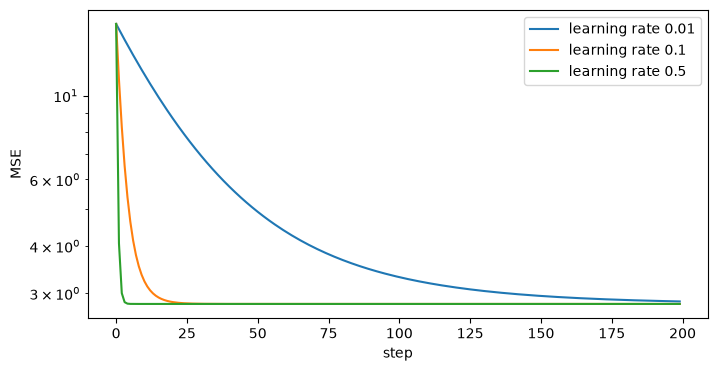

gradient descent: [ 0.6893  3.4261  1.0981  1.0541 -0.0129]
normal equations: [ 0.6893  3.4261  1.0981  1.0541 -0.0129]


In [5]:
def gradient_descent(X, y, lr=0.1, steps=500):
    b = np.zeros(X.shape[1])
    history = []
    for _ in range(steps):
        residual = X @ b - y
        history.append((residual ** 2).mean())        # MSE before this step
        grad = 2 / len(y) * X.T @ residual
        b = b - lr * grad                                # step downhill
    return b, history

# Gradient descent needs features on similar scales: standardise them (not the column of ones)
Xs = X.copy(); Xs[:, 1:] = (X[:, 1:] - X[:, 1:].mean(0)) / X[:, 1:].std(0)
fig, ax = plt.subplots()
for lr in [0.01, 0.1, 0.5]:
    b, hist = gradient_descent(Xs, y, lr=lr, steps=200)
    ax.plot(hist, label=f"learning rate {lr}")
ax.set_yscale("log"); ax.set_xlabel("step"); ax.set_ylabel("MSE"); ax.legend(); plt.show()
b_gd, _ = gradient_descent(Xs, y, lr=0.1, steps=2000)
ols_s = np.linalg.solve(Xs.T @ Xs, Xs.T @ y)
print("gradient descent:", b_gd.round(4)); print("normal equations:", ols_s.round(4))

Too small a learning rate crawls; a good one converges quickly; try `lr=1.1` and the loss **explodes**. That is the
same learning-rate trade-off you set as a hyperparameter in neural networks. Unscaled features make the loss surface
long and narrow, which is why scaling matters for gradient-based models.

## 3. Logistic regression from scratch
Predict a probability with the sigmoid of a linear score; learn by gradient descent on the log-loss. The gradient is $\tfrac{1}{n} X^\top (p - y)$.

### Exercise 2

Write a function `sigmoid(z)` that returns 1 / (1 + e^(−z)) and works on NumPy arrays.

<details><summary>Hint</summary>

`def sigmoid(z): return 1 / (1 + np.exp(-z))`

</details>

In [6]:
# Your code here

In [7]:
check("09.2");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 09.2: not answered yet. Store your answer in `sigmoid`.


In [8]:
cr = pd.read_csv(DATA + "credit_default.csv")
feats = ["income_k", "debt_to_income", "fico", "loan_to_value", "years_employed", "home_owner"]
Z = (cr[feats] - cr[feats].mean()) / cr[feats].std()
Xc = np.column_stack([np.ones(len(cr)), Z.to_numpy()]); yc = cr["default"].to_numpy()

def _sigmoid(z):                       # reference version so this cell runs before you finish Exercise 2
    return 1 / (1 + np.exp(-z))

def fit_logistic(X, y, lr=0.5, steps=3000):
    b = np.zeros(X.shape[1])
    for _ in range(steps):
        p = _sigmoid(X @ b)
        b -= lr * X.T @ (p - y) / len(y)
    return b

b_log = fit_logistic(Xc, yc)
from sklearn.linear_model import LogisticRegression
sk = LogisticRegression(C=1e6, max_iter=5000).fit(Z, yc)          # C huge = (almost) no penalty
print(pd.DataFrame({"from scratch": b_log, "scikit-learn": np.r_[sk.intercept_, sk.coef_[0]]}, index=["const"] + feats).round(4))
p = _sigmoid(Xc @ b_log)
print("log-loss:", round(-np.mean(yc * np.log(p) + (1 - yc) * np.log(1 - p)), 4))

                from scratch  scikit-learn
const                -1.9708       -1.9706
income_k             -0.2638       -0.2636
debt_to_income        0.7922        0.7921
fico                 -1.2962       -1.2959
loan_to_value         0.5503        0.5502
years_employed       -0.2024       -0.2018
home_owner           -0.2585       -0.2585
log-loss: 0.3798


## 4. Ridge regression and the coefficient path
Ridge adds λ to the diagonal: $\hat b = (X^\top X + \lambda I)^{-1} X^\top y$. As λ grows, every coefficient shrinks toward zero.

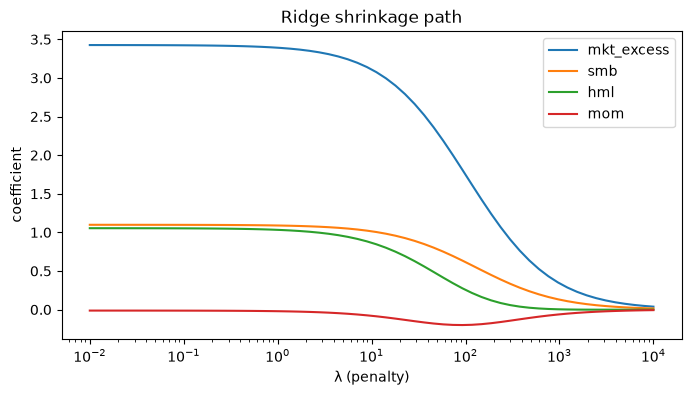

In [9]:
lams = np.logspace(-2, 4, 60); I = np.eye(Xs.shape[1]); I[0, 0] = 0          # don't penalise the intercept
path = np.array([np.linalg.solve(Xs.T @ Xs + lam * I, Xs.T @ y) for lam in lams])
for j, c in enumerate(cols, start=1):
    plt.plot(lams, path[:, j], label=c)
plt.xscale("log"); plt.xlabel("λ (penalty)"); plt.ylabel("coefficient"); plt.legend(); plt.title("Ridge shrinkage path"); plt.show()

## 5. A decision tree split from scratch
A tree tries every threshold on every feature and keeps the split that leaves the two sides purest. Purity is measured with Gini impurity: $1 - \sum_k p_k^2$.

### Exercise 3

Write `gini(labels)` that takes an array of 0/1 labels and returns the Gini impurity. `gini(np.array([0, 1, 1, 1]))` should be 0.375.

<details><summary>Hint</summary>

Share of ones: `p = labels.mean()`; then `1 - p**2 - (1 - p)**2`.

</details>

In [10]:
# Your code here

In [11]:
check("09.3");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 09.3: not answered yet. Store your answer in `gini`.


In [12]:
def _gini(lbl):
    p = lbl.mean() if len(lbl) else 0
    return 1 - p ** 2 - (1 - p) ** 2

def best_split(x, y):
    values = np.unique(x)
    best = (None, np.inf)
    for lo, hi in zip(values[:-1], values[1:]):
        t = (lo + hi) / 2
        left, right = y[x <= t], y[x > t]
        score = (len(left) * _gini(left) + len(right) * _gini(right)) / len(y)
        if score < best[1]:
            best = (t, score)
    return best

for f in ["debt_to_income", "loan_to_value", "income_k"]:
    t, s = best_split(cr[f].to_numpy(), yc)
    print(f"{f:15} best threshold {t:8.2f}  weighted Gini {s:.4f}   (no split: {_gini(yc):.4f})")

debt_to_income  best threshold    35.25  weighted Gini 0.3113   (no split: 0.3274)
loan_to_value   best threshold    87.75  weighted Gini 0.3213   (no split: 0.3274)
income_k        best threshold    21.85  weighted Gini 0.3245   (no split: 0.3274)


### Exercise 4

Use `best_split` on the `fico` column. Store the best threshold in `best_threshold_fico`. Is FICO a better first split than the three features above? Compare with `DecisionTreeClassifier(max_depth=1).fit(cr[['fico']], yc).tree_.threshold[0]`.

In [13]:
# Your code here

In [14]:
check("09.4");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 09.4: not answered yet. Store your answer in `best_threshold_fico`.


## 6. K-means from scratch

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
co = pd.read_csv(DATA + "company_fundamentals.csv")
fts = ["revenue_growth", "operating_margin", "pe_ratio", "dividend_yield", "beta", "debt_to_equity"]
Xk = StandardScaler().fit_transform(co[fts])

def kmeans_scratch(X, k, iters=100, seed=0):
    rng = np.random.default_rng(seed)
    C = X[rng.choice(len(X), k, replace=False)]                      # start: k random points
    for _ in range(iters):
        dist = ((X[:, None, :] - C[None, :, :]) ** 2).sum(axis=2)     # n x k squared distances
        labels = dist.argmin(axis=1)                                  # assign step
        newC = np.array([X[labels == j].mean(0) if (labels == j).any() else C[j] for j in range(k)])
        if np.allclose(newC, C):
            break
        C = newC                                                      # update step
    return labels, C

best = min((kmeans_scratch(Xk, 5, seed=s) for s in range(10)), key=lambda r: ((Xk - r[1][r[0]]) ** 2).sum())
print("from scratch WCSS:", round(((Xk - best[1][best[0]]) ** 2).sum(), 2))
print("scikit-learn WCSS:", round(KMeans(5, n_init=10, random_state=0).fit(Xk).inertia_, 2))
print(pd.crosstab(best[0], co["true_sector"]))

from scratch WCSS: 167.98
scikit-learn WCSS: 167.98
true_sector  banks  consumer_staples  energy  growth_tech  utilities
row_0                                                               
0                0                 1       0            0         29
1                0                 0       0           30          0
2                0                29       0            0          1
3                0                 0      30            0          0
4               30                 0       0            0          0


### Exercise 5

Write `wcss(X, labels, centroids)` that returns the within-cluster sum of squares.

<details><summary>Hint</summary>

Index the centroids by label: `((X - centroids[labels]) ** 2).sum()`.

</details>

In [16]:
# Your code here

In [17]:
check("09.5");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 09.5: not answered yet. Store your answer in `wcss`.


## 7. A neural network from scratch (one hidden layer)
Forward pass: hidden = ReLU(X W₁ + b₁); output = sigmoid(hidden W₂ + b₂). Backpropagation is the chain rule applied layer by layer.

In [18]:
def train_nn(X, y, hidden=8, lr=0.1, epochs=3000, seed=0):
    rng = np.random.default_rng(seed)
    W1 = rng.normal(0, 0.5, (X.shape[1], hidden)); b1 = np.zeros(hidden)
    W2 = rng.normal(0, 0.5, hidden); b2 = 0.0
    for _ in range(epochs):
        h_in = X @ W1 + b1; h = np.maximum(0, h_in)          # forward: hidden layer with ReLU
        p = _sigmoid(h @ W2 + b2)                            # forward: output probability
        d_out = (p - y) / len(y)                             # backward: log-loss gradient at the output
        gW2 = h.T @ d_out; gb2 = d_out.sum()
        d_h = np.outer(d_out, W2) * (h_in > 0)               # chain rule through ReLU
        gW1 = X.T @ d_h; gb1 = d_h.sum(0)
        W1 -= lr * gW1; b1 -= lr * gb1; W2 -= lr * gW2; b2 -= lr * gb2
    return lambda Xn: _sigmoid(np.maximum(0, Xn @ W1 + b1) @ W2 + b2)

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
Ztr, Zte, ytr, yte = train_test_split(Z.to_numpy(), yc, test_size=0.25, random_state=0, stratify=yc)
net = train_nn(Ztr, ytr)
lin = fit_logistic(np.column_stack([np.ones(len(Ztr)), Ztr]), ytr)
print("test AUC, neural net from scratch:", round(roc_auc_score(yte, net(Zte)), 3))
print("test AUC, logistic from scratch:  ", round(roc_auc_score(yte, _sigmoid(np.column_stack([np.ones(len(Zte)), Zte]) @ lin)), 3))

test AUC, neural net from scratch: 0.827
test AUC, logistic from scratch:   0.83


That is the whole idea of deep learning: more layers, more nodes, the same forward pass and chain rule.
Libraries like PyTorch compute the gradients automatically, but the algorithm is exactly this loop.

---
## Solutions

In [19]:
b_ne = np.linalg.solve(X.T @ X, X.T @ y)
print("1) normal equations:", b_ne.round(4))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def gini(labels):
    p = np.mean(labels) if len(labels) else 0
    return 1 - p ** 2 - (1 - p) ** 2

best_threshold_fico, s = best_split(cr["fico"].to_numpy(), yc)
print(f"4) fico best threshold {best_threshold_fico:.1f}, weighted Gini {s:.4f} → the best of the four features")

def wcss(X, labels, centroids):
    return ((X - centroids[labels]) ** 2).sum()

check_all("09")

1) normal equations: [ 0.1572  1.0194  0.4239  0.3459 -0.0033]
4) fico best threshold 648.5, weighted Gini 0.2952 → the best of the four features
✅ Exercise 09.2: correct.
✅ Exercise 09.1: correct.
✅ Exercise 09.3: correct.
✅ Exercise 09.4: correct.
✅ Exercise 09.5: correct.

5 of 5 exercises correct.
